In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *


IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 229483-BUF
Expiration date: 31-Mar-2024


In [2]:
def get_obs_data(var,season, mem, resample_interval):
    
    file_name_setup = [var+'_Amon_d4PDF_HPB_m','_1951-2021.nc']
        
    da = xr.open_dataarray("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/"+var+"/full/" + file_name_setup[0] + mem + "_gaussian_" + season + file_name_setup[1])

    if resample_interval != 'annual':
        da = da.resample(time=resample_interval).mean()

    da = da.sel(time=slice("1951","2021"))
    da = da.stack(pixel=("lat", "lon"))
    da = da.dropna("pixel", how="all")        
    
    array = da.values.flatten()
    
    del da
    
    return(array)

def get_mean_and_noise(var,season,scen, mem, resample_interval):
    
    if scen == 'HPB':
        file_name_setup = [var+'_Amon_d4PDF_HPB_m','_1951-2021.nc']
    if scen == 'HPB_NAT':
        file_name_setup = [var+'_Amon_d4PDF_HPB_NAT_m','_1951-2021.nc']

    ens_mean_sub_member = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/'+var+'/full/means/' + file_name_setup[0][:-1] + 'EnsMeanSub_m' + mem + "_gaussian_" + season + file_name_setup[1])
    
    if resample_interval != 'annual':
        ens_mean_sub_member = ens_mean_sub_member.resample(time=resample_interval).mean()
        
    ens_mean_sub_member = ens_mean_sub_member.sel(time=slice("1951","2021"))
    
    noise = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        if number == mem:
            continue

        mem_da = xr.open_dataarray("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/"+var+"/full/" + file_name_setup[0] + number + "_gaussian_" + season + file_name_setup[1])

        if resample_interval != 'annual':
            mem_da = mem_da.resample(time=resample_interval).mean()
            
        mem_da = mem_da.sel(time=slice("1951","2021"))
        
        diff = mem_da - ens_mean_sub_member

        diff = diff.stack(pixel=("lat", "lon"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
        del mem_da
        del diff_array

    ens_mean_sub_member = ens_mean_sub_member.stack(pixel=("lat", "lon"))# Create a MultiIndex
    ens_mean_sub_member = ens_mean_sub_member.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean_sub_member.values.flatten()

    del ens_mean_sub_member
    
    return((ens_mean_array, np.array(noise)))


def scan_optimal_fingerprinting(var,season,number,resample_interval):
    
    IDL.retall

    all_ens_mean,noise_all = get_mean_and_noise(var,season,'HPB', number, resample_interval)
    nat_ens_mean,noise_nat = get_mean_and_noise(var,season,'HPB_NAT', number, resample_interval)

    data_obs = get_obs_data(var,season, number, resample_interval)
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    data_noise_1 = np.concatenate((noise_all[:49],noise_nat[:49]))
    data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))

    trunc = np.array([i for i in range(3,98)])

    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []

    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est")

    #beta_est = IDL.beta_est
    scan_beta_est = IDL.scan_beta_est
    
    return scan_beta_est




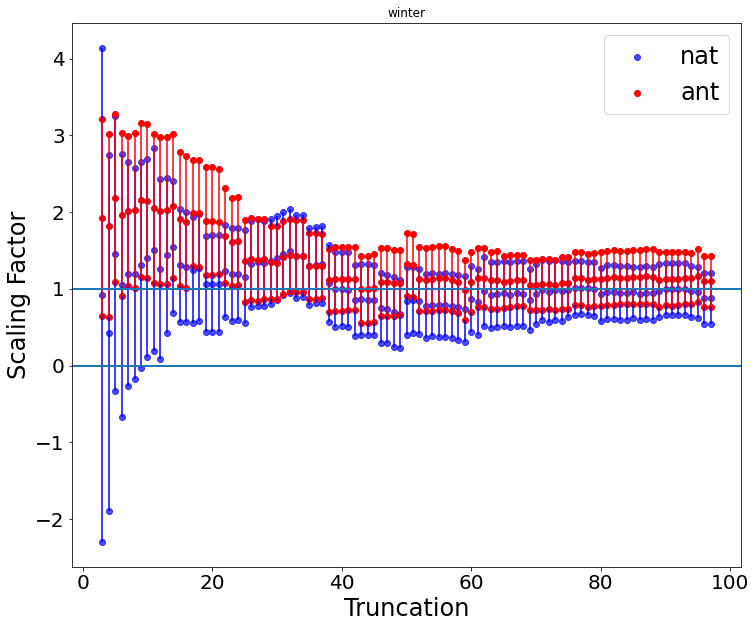

In [14]:

fig,axs = plt.subplots(figsize=(12,10))

scan_beta_est = scan_optimal_fingerprinting('TA','winter','050','annual')

for j in range(len(scan_beta_est)):

    beta_est = scan_beta_est[j]
    best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
    best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

    axs.scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
    axs.scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

    axs.vlines(j+3,low_2,up_2,colors=['blue'])
    axs.vlines(j+3,low_1,up_1,colors=['red'])

    axs.axhline(0,-0.5,1.5)
    axs.axhline(1,-0.5,1.5)


axs.set_title('winter')
axs.set_xlabel('Truncation', fontsize=24)
axs.set_ylabel('Scaling Factor', fontsize=24)
axs.legend(prop={'size': 24})

axs.xaxis.set_tick_params(labelsize=20)
axs.yaxis.set_tick_params(labelsize=20)

plt.savefig('/nesi/project/niwa00015/queenle/plots/d4PDF/perfect_model/PM_highres_example.png')
plt.show()

